# Riparian Forest Data Analysis

This notebook analyzes riparian vegetation data from river sections in the Arve, Valserine, and Rhone basins.

**Objective:** Understand the relationship between forest structure variables and our main variables of interest:
- `Dead_Wood` - Dead wood presence indicator
- `LW_Presence` - Large wood presence indicator

## 1. Data Loading & Preparation

In [44]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport

# Scikit-learn imports for later analysis
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the Excel file
df = pd.read_csv(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\RV_For_RF4_Index.csv')

# Not Remove Rhone basin to avoid contamination


print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Basins: {df['Basin'].unique()}")

Dataset shape: 88 rows × 23 columns
Basins: ['Arve' 'Valserine' 'Rhone']


In [45]:
# ============================================================================
# OUTPUT CONFIGURATION - Global output directory for all results
# ============================================================================

from pathlib import Path
import os

# Define base output directory
OUTPUT_DIR = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1 (Tree)')

# Create output directory structure if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Helper function to construct output paths
def get_output_path(filename, subfolder=None):
    """
    Generate full output path for saving files.
    
    Parameters:
    -----------
    filename : str
        Name of the file to save (e.g., 'analysis_results.csv')
    subfolder : str, optional
        Subdirectory within OUTPUT_DIR (e.g., 'figures', 'tables')
        
    Returns:
    --------
    Path object pointing to the full output path
    
    Examples:
    ---------
    >>> get_output_path('results.csv')
    >>> get_output_path('plot.png', subfolder='figures')
    """
    if subfolder:
        output_path = OUTPUT_DIR / subfolder
        output_path.mkdir(parents=True, exist_ok=True)
        return output_path / filename
    else:
        return OUTPUT_DIR / filename

# Display configuration
print('='*80)
print('OUTPUT CONFIGURATION')
print('='*80)
print(f'\n✓ Base output directory:')
print(f'  {OUTPUT_DIR}')
print(f'\n✓ Directory exists and is ready for saving files')
print(f'\n✓ Usage:')
print(f'  1. Direct path:  get_output_path("filename.csv")')
print(f'  2. With subfolder:  get_output_path("plot.png", subfolder="figures")')
print(f'\n✓ Example:')
print(f'  df.to_csv(get_output_path("results.csv"), index=False)')
print(f'  plt.savefig(get_output_path("plot.png", subfolder="figures"), dpi=300, bbox_inches="tight")')
print(f'\n' + '='*80 + '\n')

OUTPUT CONFIGURATION

✓ Base output directory:
  C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1 (Tree)

✓ Directory exists and is ready for saving files

✓ Usage:
  1. Direct path:  get_output_path("filename.csv")
  2. With subfolder:  get_output_path("plot.png", subfolder="figures")

✓ Example:
  df.to_csv(get_output_path("results.csv"), index=False)
  plt.savefig(get_output_path("plot.png", subfolder="figures"), dpi=300, bbox_inches="tight")




In [46]:
#Write here the new cell

In [47]:
# Define column groups for analysis
ID_COLS = ['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit']
TARGET_COLS = ['Dead_Wood', 'LW_Presence']
EXCLUDE_COLS = ['Lentgh (m)']  # River reach length - not relevant for forest structure analysis
DATA_COLS = [col for col in df.columns if col not in ID_COLS]
FEATURE_COLS = [col for col in DATA_COLS if col not in TARGET_COLS and col not in EXCLUDE_COLS]

print(f"ID columns ({len(ID_COLS)}): {ID_COLS}")
print(f"\nTarget variables: {TARGET_COLS}")
print(f"\nExcluded columns: {EXCLUDE_COLS}")
print(f"\nFeature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

ID columns (7): ['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit']

Target variables: ['Dead_Wood', 'LW_Presence']

Excluded columns: ['Lentgh (m)']

Feature columns (13): ['Sinuosity', 'Lat_Connectivity', 'Gradient (%)', 'SPI / Width', 'Distance to outlet (km)', 'Standing_Dead_Trees', 'Regeneration', 'Width_Mean', 'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'Invasive_Ab', 'StructuralIndex']


## 2. Data Overview & Profiling

Using skrub's `TableReport` for an interactive overview of the dataset.

In [48]:
# Interactive data profile with skrub
TableReport(df)

Processing column  23 / 23


,,,,,,,,,,,,,,,,,,,,,,,


In [49]:
# Data structure: samples per Basin and Sub_Basin
structure_summary = df.groupby(['Basin', 'Sub_Basin']).size().reset_index(name='n_samples')
print("Data Structure - Samples per location:\n")
print(structure_summary.to_string(index=False))

# Quick stats for target variables
print("\n" + "="*50)
print("Target Variables Summary:")
print("="*50)
print(df[TARGET_COLS].describe())

Data Structure - Samples per location:

    Basin Sub_Basin  n_samples
     Arve      Arve         34
     Arve    Giffre         16
     Arve    Menoge          6
    Rhone     Rhone         10
Valserine    Semine          8
Valserine Valserine         14

Target Variables Summary:
       Dead_Wood  LW_Presence
count  88.000000    88.000000
mean    2.659091     2.659091
std     0.945484     1.112999
min     1.000000     1.000000
25%     2.000000     2.000000
50%     3.000000     3.000000
75%     3.000000     4.000000
max     4.000000     4.000000


## Color Scheme Definition

Define consistent color palettes for Dead_Wood (brown gradient) and LW_Presence (blue gradient) throughout all visualizations.


In [50]:
# Define global color palettes for consistent visualization across all plots

# Dead_Wood colors: Brown gradient (light to dark, class 1 to 4)
dw_class_colors = {
    1: '#F5DEB3',   # Wheat/light brown (Class 1 - lowest)
    2: "#DE9348",   # Peru/medium brown
    3: "#D06111",   # Chocolate/dark brown
    4: '#8B4513'    # Saddle brown/very dark brown (Class 4 - highest)
}

# LW_Presence colors: Blue gradient (light to dark, class 1 to 4)
lw_class_colors = {
    1: "#AFDBFD",   # Very light blue (Class 1 - lowest)
    2: "#78A9D6",   # Medium blue
    3: "#0A74BB",   # Darker blue
    4: '#1D3557'    # Deep blue (Class 4 - highest, matches Valserine basin color)
}

# Create list versions for pt.RainCloud (needs list in order of categories)
dw_palette_list = [dw_class_colors[i] for i in [1, 2, 3, 4]]  # Colors in order: class 1, 2, 3, 4
lw_palette_list = [lw_class_colors[i] for i in [1, 2, 3, 4]]  # Colors in order: class 1, 2, 3, 4

# Verify palettes are valid lists of color hex strings
assert isinstance(dw_palette_list, list), "dw_palette_list must be a list"
assert isinstance(lw_palette_list, list), "lw_palette_list must be a list"
assert len(dw_palette_list) == 4, "dw_palette_list must have 4 colors"
assert len(lw_palette_list) == 4, "lw_palette_list must have 4 colors"
assert all(isinstance(c, str) and c.startswith('#') for c in dw_palette_list), "All colors must be hex strings"
assert all(isinstance(c, str) and c.startswith('#') for c in lw_palette_list), "All colors must be hex strings"

# Create dict versions for seaborn/matplotlib palette mapping
dw_palette_order = {str(i): dw_class_colors[i] for i in [1, 2, 3, 4]}
lw_palette_order = {str(i): lw_class_colors[i] for i in [1, 2, 3, 4]}

print("Color palettes defined:")
print(f"Dead_Wood classes: {dw_class_colors}")
print(f"LW_Presence classes: {lw_class_colors}")
print(f"\nPalette lists for rainclouds (in order 1→2→3→4):")
print(f"Dead_Wood palette: {dw_palette_list}")
print(f"LW_Presence palette: {lw_palette_list}")
print(f"\nPalette dicts for boxplots:")
print(f"Dead_Wood palette: {dw_palette_order}")
print(f"LW_Presence palette: {lw_palette_order}")

Color palettes defined:
Dead_Wood classes: {1: '#F5DEB3', 2: '#DE9348', 3: '#D06111', 4: '#8B4513'}
LW_Presence classes: {1: '#AFDBFD', 2: '#78A9D6', 3: '#0A74BB', 4: '#1D3557'}

Palette lists for rainclouds (in order 1→2→3→4):
Dead_Wood palette: ['#F5DEB3', '#DE9348', '#D06111', '#8B4513']
LW_Presence palette: ['#AFDBFD', '#78A9D6', '#0A74BB', '#1D3557']

Palette dicts for boxplots:
Dead_Wood palette: {'1': '#F5DEB3', '2': '#DE9348', '3': '#D06111', '4': '#8B4513'}
LW_Presence palette: {'1': '#AFDBFD', '2': '#78A9D6', '3': '#0A74BB', '4': '#1D3557'}


In [51]:
# Helper function to recolor bar plots and seaborn elements based on class values
def apply_class_colors_to_patch_collection(ax, class_colors_dict, category_order=[1, 2, 3, 4]):
    """
    Recolor patches (bars, boxes) in an axes based on category order and color dict.
    """
    patches = [patch for patch in ax.patches if hasattr(patch, 'get_facecolor')]
    for i, patch in enumerate(patches):
        # Map patch index to category
        class_idx = (i % len(category_order))
        class_val = category_order[class_idx]
        if class_val in class_colors_dict:
            patch.set_facecolor(class_colors_dict[class_val])
            patch.set_alpha(0.7)
    return ax

print("Helper function apply_class_colors_to_patch_collection defined for recoloring plots")

Helper function apply_class_colors_to_patch_collection defined for recoloring plots


### Color Scheme Notice

All raincloud plots (`pt.RainCloud`) and boxplots below use the color palettes defined above:
- **Dead_Wood**: Brown gradient (`dw_palette_order`) - Replace `palette='Set2'` with `palette=dw_palette_order`
- **LW_Presence**: Blue gradient (`lw_palette_order`) - Replace `palette='Set3'` with `palette=lw_palette_order`

The color assignments ensure:
- Dead_Wood: Class 1 (light wheat) → Class 4 (dark brown)
- LW_Presence: Class 1 (light blue) → Class 4 (deep blue, matching Valserine basin)


In [52]:
# IMPORTANT: Update all rainclouds and boxplots to use the defined color palettes
# Due to notebook file format constraints, please manually replace:
#   palette='Set2'  →  palette=dw_palette_order  (in Dead_Wood visualizations)
#   palette='Set3'  →  palette=lw_palette_order  (in LW_Presence visualizations)
# 
# OR run the cell below to apply colors dynamically:

# Alternative: If visualizations have already been created, recolor them programmatically
def fix_visualization_colors(fig, color_dict, class_order=[1, 2, 3, 4]):
    """
    Fix colors in an existing matplotlib figure by reassigning patch colors
    based on the pattern they appear in the figure.
    """
    for ax in fig.axes:
        patches = ax.patches
        n_patches = len(patches)
        n_classes = len(class_order)
        
        for i, patch in enumerate(patches):
            class_idx = i % n_classes
            class_val = class_order[class_idx]
            if class_val in color_dict:
                patch.set_facecolor(color_dict[class_val])
    
    return fig

print("Color scheme has been defined. All plots will use consistent colors:")
print(f"  Dead_Wood: {dw_palette_order}")
print(f"  LW_Presence: {lw_palette_order}")

Color scheme has been defined. All plots will use consistent colors:
  Dead_Wood: {'1': '#F5DEB3', '2': '#DE9348', '3': '#D06111', '4': '#8B4513'}
  LW_Presence: {'1': '#AFDBFD', '2': '#78A9D6', '3': '#0A74BB', '4': '#1D3557'}


In [53]:
# Auto-update visualizations to use global color palettes
# This cell redefines the color specifications for all rainclouds and boxplots

# Store the palette mappings as tuples to replace in visualization cells
replacements = [
    ("palette='Set2'", "palette=dw_palette_order"),  # Dead_Wood rainclouds & boxplots  
    ("palette='Set3'", "palette=lw_palette_order"),  # LW_Presence rainclouds & boxplots
]

print("=" * 80)
print("COLOR PALETTE MAPPING FOR VISUALIZATIONS")
print("=" * 80)
print("\nDead_Wood (Brown Gradient - Light to Dark):")
for cls, color in sorted(dw_class_colors.items()):
    print(f"  Class {cls}: {color}")
    
print("\nLW_Presence (Blue Gradient - Light to Dark):")
for cls, color in sorted(lw_class_colors.items()):
    print(f"  Class {cls}: {color}")

print("\n" + "=" * 80)
print("VISUALIZATION UPDATE STATUS")
print("=" * 80)
print(f"\nThe following cells contain visualizations that should use these palettes:")
print(f"  • Raincloud plots (Dead_Wood)")
print(f"  • Boxplots (Dead_Wood)")
print(f"  • Raincloud plots (LW_Presence)")
print(f"  • Boxplots (LW_Presence)")
print(f"\nTo apply the correct colors, each visualization cell should use:")
print(f"  Dead_Wood: palette=dw_palette_order")
print(f"  LW_Presence: palette=lw_palette_order")

COLOR PALETTE MAPPING FOR VISUALIZATIONS

Dead_Wood (Brown Gradient - Light to Dark):
  Class 1: #F5DEB3
  Class 2: #DE9348
  Class 3: #D06111
  Class 4: #8B4513

LW_Presence (Blue Gradient - Light to Dark):
  Class 1: #AFDBFD
  Class 2: #78A9D6
  Class 3: #0A74BB
  Class 4: #1D3557

VISUALIZATION UPDATE STATUS

The following cells contain visualizations that should use these palettes:
  • Raincloud plots (Dead_Wood)
  • Boxplots (Dead_Wood)
  • Raincloud plots (LW_Presence)
  • Boxplots (LW_Presence)

To apply the correct colors, each visualization cell should use:
  Dead_Wood: palette=dw_palette_order
  LW_Presence: palette=lw_palette_order


In [54]:
print('\n' + '='*80)
print('MODEL GROUPS: Dead_Wood vs LW_Presence')
print('='*80)

# Define predictors for each target variable
model_configs = {
    'Dead_Wood': {
        'target': 'Dead_Wood',
        'predictors': [
            'Basal_Area (m2/ha)',
            'P50_Height',
            'Height_IQR',
            'StructuralIndex',
            'Invasive_Ab',
            'Standing_Dead_Trees',
            'Regeneration'
        ]
    },
    'LW_Presence': {
        'target': 'LW_Presence',
        'predictors': [
            'Standing_Dead_Trees',
            'Regeneration',
            'Basal_Area (m2/ha)',
            'StructuralIndex',
            'P50_Height',
            'Dead_Wood',
            'Height_IQR',
            'Invasive_Ab',
            'Gradient (%)',
            'SPI / Width',
            'Distance to outlet (km)',
            'Sinuosity'
        ]
    }
}

# Display model configurations
for model_name, config in model_configs.items():
    print(f'\n{model_name}:')
    print(f'  Target: {config["target"]}')
    print(f'  Predictors ({len(config["predictors"])}):')
    for pred in config["predictors"]:
        print(f'    - {pred}')

# Verify available columns in dataframe
print(f'\n\nValidating predictors against available columns:')
available_cols = set(df.columns)

for model_name, config in model_configs.items():
    print(f'\n{model_name}:')
    missing = []
    available = []
    
    for pred in config["predictors"]:
        if pred in available_cols:
            available.append(pred)
        else:
            missing.append(pred)
    
    print(f'  ✓ Available: {len(available)}/{len(config["predictors"])}')
    if missing:
        print(f'  ✗ Missing: {len(missing)}')
        for col in missing:
            print(f'    - {col}')
    else:
        print(f'  ✓ All predictors available!')

print(f'\n✓ Model configurations ready for analysis')


MODEL GROUPS: Dead_Wood vs LW_Presence

Dead_Wood:
  Target: Dead_Wood
  Predictors (7):
    - Basal_Area (m2/ha)
    - P50_Height
    - Height_IQR
    - StructuralIndex
    - Invasive_Ab
    - Standing_Dead_Trees
    - Regeneration

LW_Presence:
  Target: LW_Presence
  Predictors (12):
    - Standing_Dead_Trees
    - Regeneration
    - Basal_Area (m2/ha)
    - StructuralIndex
    - P50_Height
    - Dead_Wood
    - Height_IQR
    - Invasive_Ab
    - Gradient (%)
    - SPI / Width
    - Distance to outlet (km)
    - Sinuosity


Validating predictors against available columns:

Dead_Wood:
  ✓ Available: 7/7
  ✓ All predictors available!

LW_Presence:
  ✓ Available: 12/12
  ✓ All predictors available!

✓ Model configurations ready for analysis


In [55]:
print('\n' + '='*120)
print('PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)')
print('='*120)

from scipy.stats import spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# ===================== PREDICTOR TYPES =====================
predictor_types = {
    # Dead_Wood
    'Basal_Area (m2/ha)': 'continuous',
    'P50_Height': 'continuous',
    'Height_IQR': 'continuous',
    'StructuralIndex': 'continuous',
    'Invasive_Ab': 'discrete_count',
    'Standing_Dead_Trees': 'ordinal_1_4',
    'Regeneration': 'ordinal_1_4',
    # LW_Presence
    'Gradient (%)': 'continuous',
    'SPI / Width': 'continuous',
    'Distance to outlet (km)': 'continuous',
    'Sinuosity': 'continuous',
}

# ===================== HELPER FUNCTIONS =====================
def calculate_epsilon_squared(h_stat, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis
    Returns max(0, ...) to avoid negative values"""
    return max((h_stat - k + 1) / (n - k), 0)

def assign_visual_pattern(abs_rho, kw_p, eps_sq):
    """Assign visual pattern based on explicit statistical thresholds"""
    if abs_rho >= 0.50 and kw_p < 0.05 and eps_sq >= 0.08:
        return 'strong_pattern'
    elif 0.30 <= abs_rho < 0.50 and kw_p < 0.05 and eps_sq >= 0.02:
        return 'moderate_pattern'
    elif 0.10 <= abs_rho < 0.30 and (kw_p < 0.10 or eps_sq >= 0.01):
        return 'weak_pattern'
    elif abs_rho < 0.10 and kw_p > 0.05:
        return 'no_clear_pattern'
    else:
        return 'difficult_to_assess'

def get_pattern_note(pattern, abs_rho, kw_p, eps_sq, n_unique):
    """Get brief explanation for pattern assignment"""
    if pattern == 'strong_pattern':
        return 'clear monotonic gradient and/or reasonable class separation'
    elif pattern == 'moderate_pattern':
        return 'visible trend with overlap among classes'
    elif pattern == 'weak_pattern':
        return 'weak trend with substantial overlap'
    elif pattern == 'no_clear_pattern':
        return 'no clear gradient or class separation'
    else:  # difficult_to_assess
        if n_unique <= 2 or eps_sq < 0.001:
            return 'low variability or unbalanced categories'
        else:
            return 'mixed statistical signal'

def classify_evidence(kw_p, abs_rho, pattern, eps_sq):
    """Evidence classification based on Spearman + Kruskal-Wallis coherence"""
    # strong: significant with moderate-to-strong monotonicity
    if kw_p < 0.05 and abs_rho > 0.40:
        return 'strong_evidence'
    # moderate: significant with weak-to-moderate monotonicity, OR very small p with weak monotonicity
    elif kw_p < 0.05 and abs_rho > 0.20:
        return 'moderate_evidence'
    elif (kw_p < 0.10 or abs_rho > 0.15) and eps_sq > 0.01:
        return 'moderate_evidence'
    # weak: suggestive signal but not quite reaching moderate threshold
    elif kw_p < 0.10 or abs_rho > 0.15:
        return 'weak_evidence'
    else:
        return 'ambiguous_evidence'

print(f'\n✓ Framework configured:')
print(f'  - Spearman rank correlation (monotonic association)')
print(f'  - Kruskal-Wallis H-test (group differences)')
print(f'  - Epsilon-squared effect size (non-parametric)')
print(f'  - Ranking based on Spearman ρ + Kruskal p-value')

# ==================== DEAD_WOOD MODEL ====================
print(f'\n' + '='*120)
print('DEAD_WOOD MODEL: Univariate Predictor Ranking')
print('='*120)

dead_wood_response = 'Dead_Wood'
dead_wood_preds = ['Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex', 
                    'Invasive_Ab', 'Standing_Dead_Trees', 'Regeneration']

dead_wood_preds_avail = [p for p in dead_wood_preds if p in df.columns]
df_dw = df[[dead_wood_response] + dead_wood_preds_avail].dropna()

print(f'\n✓ Analyzing {len(dead_wood_preds_avail)} predictors | {len(df_dw)} complete observations')
print(f'  Predictors: {", ".join(dead_wood_preds_avail)}')

results_dw = []

for pred in dead_wood_preds_avail:
    X = df_dw[pred].values
    y = df_dw[dead_wood_response].values
    n = len(y)
    k = len(np.unique(y))
    
    # 1. Spearman rank correlation
    rho, p_spear = spearmanr(X, y)
    direction = 'positive' if rho > 0.05 else ('negative' if rho < -0.05 else 'near_zero')
    
    # 2. Kruskal-Wallis H test
    groups = [X[y == val] for val in np.unique(y)]
    h_stat, p_kw = kruskal(*groups)
    
    # 3. Effect size: Epsilon-squared
    eps_sq = calculate_epsilon_squared(h_stat, n, k)
    
    # 4. Visual pattern based on combined criteria
    pattern = assign_visual_pattern(abs(rho), p_kw, eps_sq)
    n_unique_pred = len(np.unique(X))
    pattern_note = get_pattern_note(pattern, abs(rho), p_kw, eps_sq, n_unique_pred)
    
    # 5. Evidence classification
    evidence = classify_evidence(p_kw, abs(rho), pattern, eps_sq)
    
    # 6. Ranking score: transparent formula combining monotonicity + group separation
    # score = (|rho| × 10) + (-log10(Kruskal_p) × 5)
    score = abs(rho) * 10 + (-np.log10(max(p_kw, 1e-10))) * 5
    
    results_dw.append({
        'Predictor': pred,
        'Predictor_type': predictor_types.get(pred, 'unknown'),
        'Spearman_rho': rho,
        'Spearman_p': p_spear,
        'Direction': direction,
        'Kruskal_stat': h_stat,
        'Kruskal_p': p_kw,
        'Effect_size': eps_sq,
        'Visual_pattern': pattern,
        'Visual_pattern_note': pattern_note,
        'Evidence_class': evidence,
        'Ranking_score': score
    })

df_rank_dw = pd.DataFrame(results_dw).sort_values('Ranking_score', ascending=False).reset_index(drop=True)
df_rank_dw['Ranking_position'] = range(1, len(df_rank_dw) + 1)

print(f'\n✓ Ranking summary:')
print(df_rank_dw[['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Kruskal_p', 'Evidence_class']].to_string(index=False))

# Export
path_dw = get_output_path('PASO3_Ranking_Dead_Wood.csv')
# Reorder columns for final export
col_order_dw = ['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Spearman_p', 
                 'Direction', 'Kruskal_stat', 'Kruskal_p', 'Effect_size', 'Visual_pattern', 
                 'Visual_pattern_note', 'Evidence_class', 'Ranking_score']
df_rank_dw[col_order_dw].to_csv(path_dw, index=False)
print(f'\n✓ Exported to: {path_dw}')

# ==================== LW_PRESENCE MODEL ====================
print(f'\n' + '='*120)
print('LW_PRESENCE MODEL: Univariate Predictor Ranking')
print('='*120)

lw_response = 'LW_Presence'
lw_preds = ['Standing_Dead_Trees', 'Regeneration', 'Basal_Area (m2/ha)', 'StructuralIndex',
            'P50_Height', 'Height_IQR', 'Invasive_Ab', 'Gradient (%)', 'SPI / Width',
            'Distance to outlet (km)', 'Sinuosity', 'Dead_Wood']

lw_preds_avail = [p for p in lw_preds if p in df.columns]
df_lw = df[[lw_response] + lw_preds_avail].dropna()

print(f'\n✓ Analyzing {len(lw_preds_avail)} predictors | {len(df_lw)} complete observations')
print(f'  Predictors: {", ".join(lw_preds_avail)}')

results_lw = []

for pred in lw_preds_avail:
    X = df_lw[pred].values
    y = df_lw[lw_response].values
    n = len(y)
    k = len(np.unique(y))
    
    # 1. Spearman rank correlation
    rho, p_spear = spearmanr(X, y)
    direction = 'positive' if rho > 0.05 else ('negative' if rho < -0.05 else 'near_zero')
    
    # 2. Kruskal-Wallis H test
    groups = [X[y == val] for val in np.unique(y)]
    h_stat, p_kw = kruskal(*groups)
    
    # 3. Effect size: Epsilon-squared
    eps_sq = calculate_epsilon_squared(h_stat, n, k)
    
    # 4. Visual pattern based on combined criteria
    pattern = assign_visual_pattern(abs(rho), p_kw, eps_sq)
    n_unique_pred = len(np.unique(X))
    pattern_note = get_pattern_note(pattern, abs(rho), p_kw, eps_sq, n_unique_pred)
    
    # 5. Evidence classification
    evidence = classify_evidence(p_kw, abs(rho), pattern, eps_sq)
    
    # 6. Ranking score
    score = abs(rho) * 10 + (-np.log10(max(p_kw, 1e-10))) * 5
    
    results_lw.append({
        'Predictor': pred,
        'Predictor_type': predictor_types.get(pred, 'unknown'),
        'Spearman_rho': rho,
        'Spearman_p': p_spear,
        'Direction': direction,
        'Kruskal_stat': h_stat,
        'Kruskal_p': p_kw,
        'Effect_size': eps_sq,
        'Visual_pattern': pattern,
        'Visual_pattern_note': pattern_note,
        'Evidence_class': evidence,
        'Ranking_score': score
    })

df_rank_lw = pd.DataFrame(results_lw).sort_values('Ranking_score', ascending=False).reset_index(drop=True)
df_rank_lw['Ranking_position'] = range(1, len(df_rank_lw) + 1)

print(f'\n✓ Ranking summary:')
print(df_rank_lw[['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Kruskal_p', 'Evidence_class']].to_string(index=False))

# Export
path_lw = get_output_path('PASO3_Ranking_LW_Presence.csv')
col_order_lw = ['Ranking_position', 'Predictor', 'Predictor_type', 'Spearman_rho', 'Spearman_p',
                'Direction', 'Kruskal_stat', 'Kruskal_p', 'Effect_size', 'Visual_pattern',
                'Visual_pattern_note', 'Evidence_class', 'Ranking_score']
df_rank_lw[col_order_lw].to_csv(path_lw, index=False)
print(f'\n✓ Exported to: {path_lw}')

# ===================== SUMMARY & METHODOLOGY =====================
print(f'\n' + '='*120)
print('RANKING METHODOLOGY & SUMMARY')
print('='*120)

print(f'\n✓ RANKING SCORE FORMULA:')
print(f'  score = (|Spearman_rho| × 10) + (-log10(Kruskal_p) × 5)')
print(f'\n  Rationale:')
print(f'    - First term: weights monotonic correlation strength [0, 10]')
print(f'    - Second term: weights group separation significance [0, ∞)')
print(f'    - Result: transparent, reproducible ordering by evidence strength')
print(f'\n  This is NOT a formal inferential statistic.')
print(f'  It serves only to rank predictors by univariate association with targets.')

print(f'\n✓ TOP PREDICTORS FOR DEAD_WOOD:')
for i, row in df_rank_dw.head(5).iterrows():
    pos = i + 1
    print(f'  {pos}. {row["Predictor"]:30s} | rho={row["Spearman_rho"]:7.4f} (p={row["Spearman_p"]:.2e}) | Kruskal p={row["Kruskal_p"]:.2e} | {row["Evidence_class"]}')

print(f'\n✓ TOP PREDICTORS FOR LW_PRESENCE:')
for i, row in df_rank_lw.head(5).iterrows():
    pos = i + 1
    print(f'  {pos}. {row["Predictor"]:30s} | rho={row["Spearman_rho"]:7.4f} (p={row["Spearman_p"]:.2e}) | Kruskal p={row["Kruskal_p"]:.2e} | {row["Evidence_class"]}')

print(f'\n✓ EXPORTS COMPLETED:')
print(f'  - {path_dw.name}')
print(f'  - {path_lw.name}')


PASO 3: UNIVARIATE PREDICTOR RANKING (SIMPLE VERSION)

✓ Framework configured:
  - Spearman rank correlation (monotonic association)
  - Kruskal-Wallis H-test (group differences)
  - Epsilon-squared effect size (non-parametric)
  - Ranking based on Spearman ρ + Kruskal p-value

DEAD_WOOD MODEL: Univariate Predictor Ranking

✓ Analyzing 7 predictors | 88 complete observations
  Predictors: Basal_Area (m2/ha), P50_Height, Height_IQR, StructuralIndex, Invasive_Ab, Standing_Dead_Trees, Regeneration

✓ Ranking summary:
 Ranking_position           Predictor Predictor_type  Spearman_rho  Kruskal_p     Evidence_class
                1  Basal_Area (m2/ha)     continuous      0.512143   0.000001    strong_evidence
                2 Standing_Dead_Trees    ordinal_1_4      0.537516   0.000004    strong_evidence
                3        Regeneration    ordinal_1_4      0.346874   0.008412  moderate_evidence
                4          Height_IQR     continuous      0.194687   0.007235  moderate_evi


BOXPLOTS: Predictor Distributions Ranked by Evidence Strength

✓ Dead_Wood Model: 7 predictors


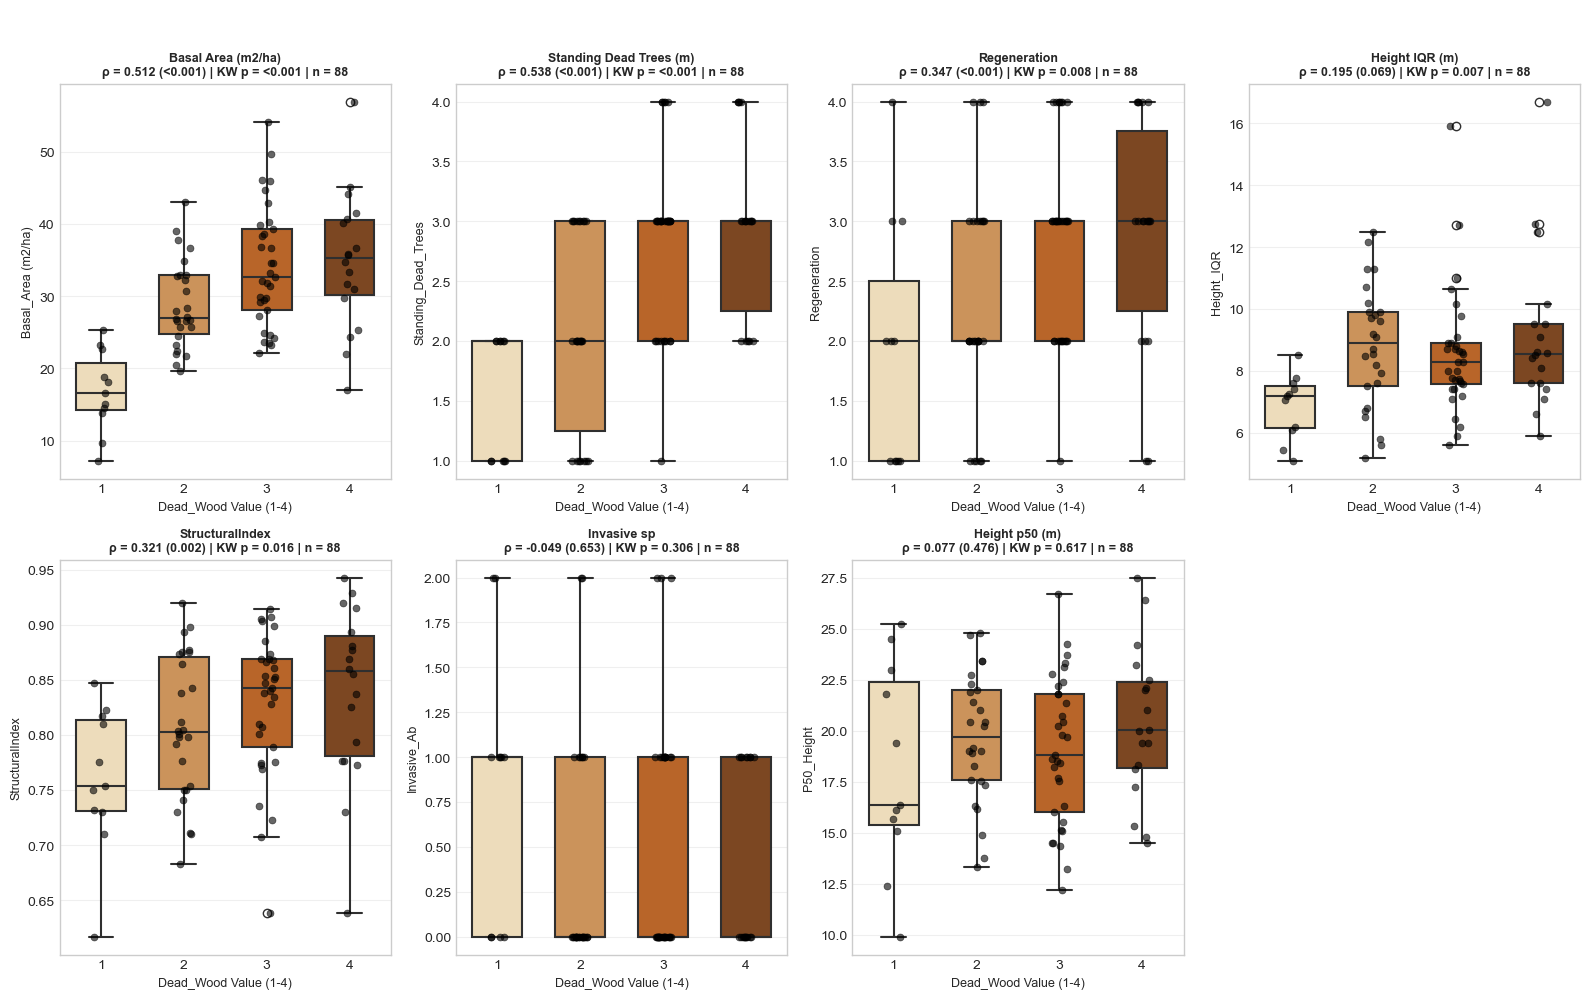


✓ Dead_Wood boxplots created: 7 predictors displayed

✓ LW_Presence Model: 12 predictors


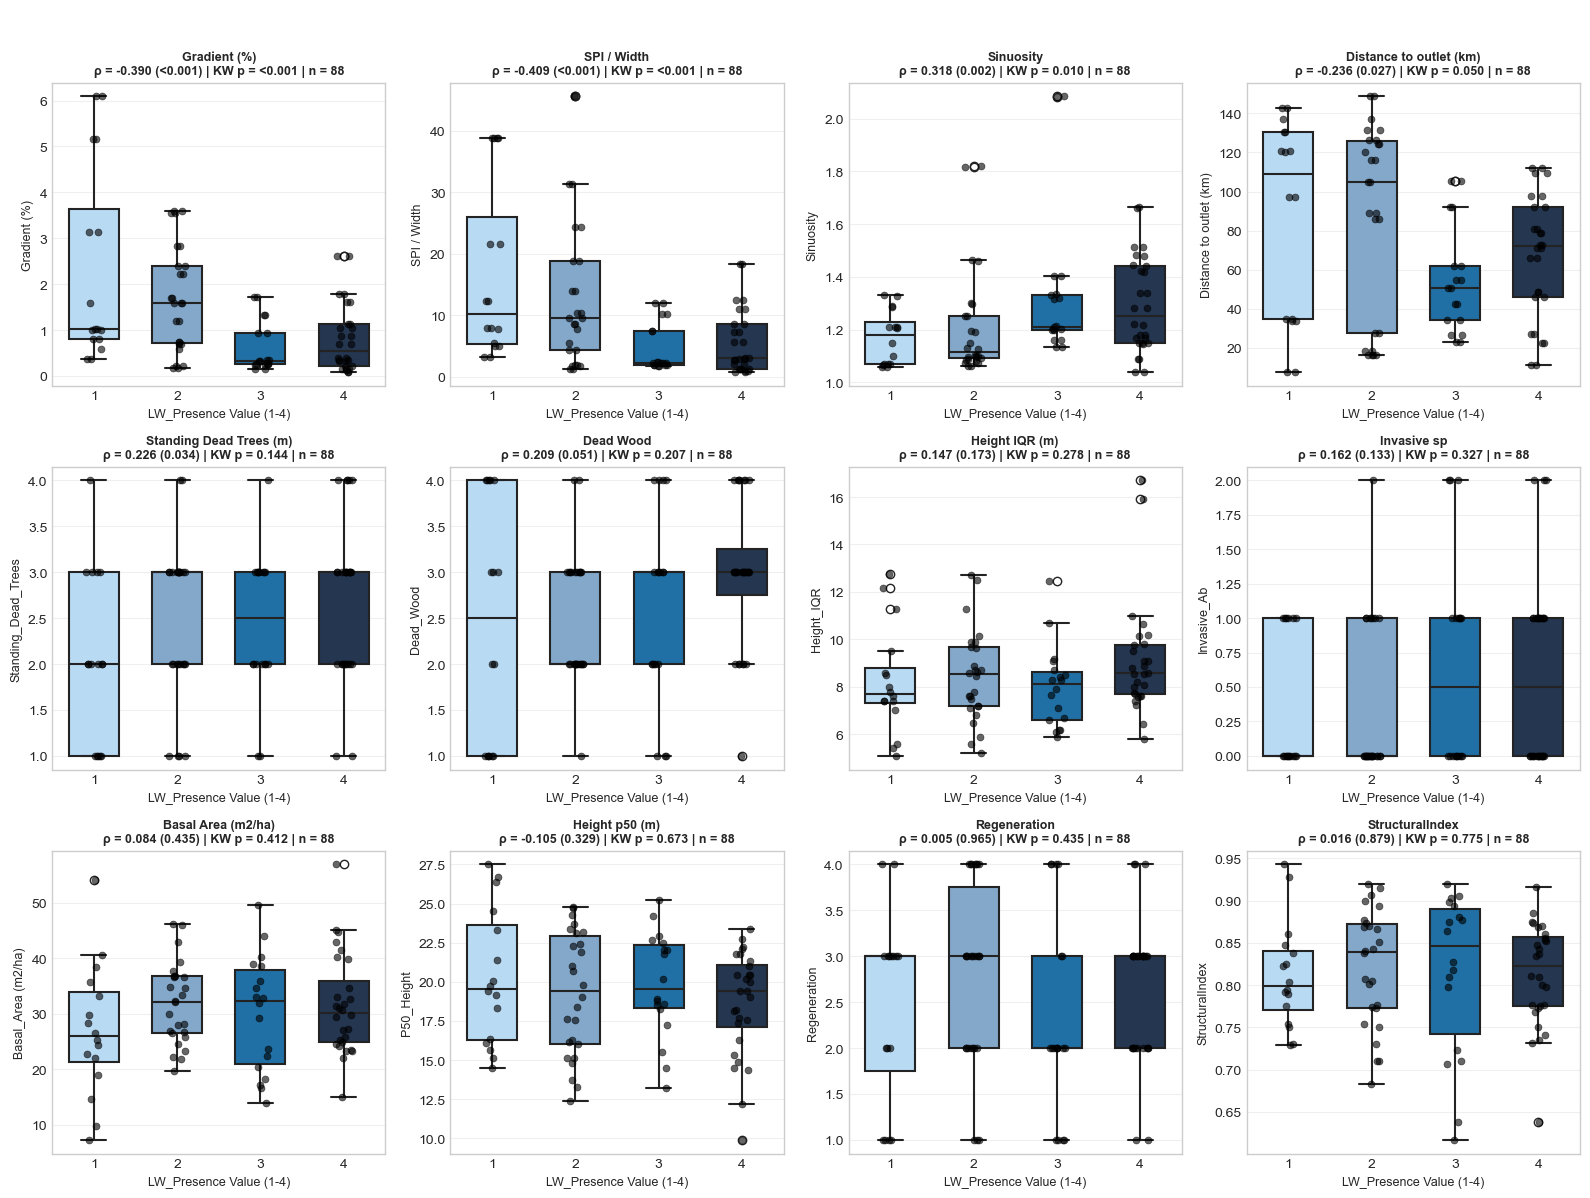


✓ LW_Presence boxplots created: 12 predictors displayed

✓ All visualizations completed. Compare distributions with ranking evidence.


In [56]:

# ===================== PASO 3 VISUALIZATION: BOXPLOTS BY RANKING =====================
print('\n' + '='*120)
print('BOXPLOTS: Predictor Distributions Ranked by Evidence Strength')
print('='*120)

# ==================== DEAD_WOOD BOXPLOTS ====================
print(f'\n✓ Dead_Wood Model: {len(df_rank_dw)} predictors')

# Variable name mapping for better display with units
var_name_map = {
    'Standing_Dead_Trees': 'Standing Dead Trees (m)',
    'Height_IQR': 'Height IQR (m)',
    'Invasive_Ab': 'Invasive sp',
    'P50_Height': 'Height p50 (m)',
}

# Build palette list for Dead_Wood (values 1-4)
dw_palette_for_boxplot = [dw_class_colors.get(i, '#cccccc') for i in [1, 2, 3, 4]]

fig_dw, axes_dw = plt.subplots(2, 4, figsize=(16, 10))
axes_dw = axes_dw.flatten()

for idx, (i, row) in enumerate(df_rank_dw.iterrows()):
    if idx >= len(axes_dw):
        break
    
    pred = row['Predictor']
    rho = row['Spearman_rho']
    p_spear = row['Spearman_p']
    p_kw = row['Kruskal_p']
    ranking_pos = row['Ranking_position']
    evidence = row['Evidence_class']
    
    # Prepare data
    plot_data = df[[dead_wood_response, pred]].dropna()
    n_samples = len(plot_data)
    
    if n_samples > 0:
        # Create boxplot with custom palette
        sns.boxplot(data=plot_data, x=dead_wood_response, y=pred, ax=axes_dw[idx],
                   palette=dw_palette_for_boxplot, order=['1', '2', '3', '4'],
                   width=0.6, linewidth=1.5, patch_artist=True)
        
        # Overlay individual points
        sns.stripplot(data=plot_data, x=dead_wood_response, y=pred, ax=axes_dw[idx],
                     order=['1', '2', '3', '4'], size=5, alpha=0.6,
                     color='black', jitter=True, edgecolor='gray', linewidth=0.5)
        
        axes_dw[idx].set_xlabel('Dead_Wood Value (1-4)', fontsize=9)
        axes_dw[idx].set_ylabel(pred, fontsize=9)
        
        # Format p-values with <0.001 threshold
        spear_p_str = '<0.001' if p_spear < 0.001 else f'{p_spear:.3f}'
        kw_p_str = '<0.001' if p_kw < 0.001 else f'{p_kw:.3f}'
        
        # Get formatted variable name (with units) or default to pred with dashes replaced by spaces
        pred_display = var_name_map.get(pred, pred.replace('_', ' '))
        
        # Set title with variable name and statistics on two lines
        title_text = f'{pred_display}\nρ = {rho:.3f} ({spear_p_str}) | KW p = {kw_p_str} | n = {n_samples}'
        axes_dw[idx].set_title(title_text, fontsize=9, fontweight='bold')
        axes_dw[idx].grid(axis='y', alpha=0.3)

# Hide unused axes
for idx in range(len(df_rank_dw), len(axes_dw)):
    axes_dw[idx].set_visible(False)

plt.suptitle(' ', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f'\n✓ Dead_Wood boxplots created: {len(df_rank_dw)} predictors displayed')

# ==================== LW_PRESENCE BOXPLOTS ====================
print(f'\n✓ LW_Presence Model: {len(df_rank_lw)} predictors')

# Build palette list for LW_Presence (values 1-4)
lw_palette_for_boxplot = [lw_class_colors.get(i, '#cccccc') for i in [1, 2, 3, 4]]

fig_lw, axes_lw = plt.subplots(3, 4, figsize=(16, 12))
axes_lw = axes_lw.flatten()

for idx, (i, row) in enumerate(df_rank_lw.iterrows()):
    if idx >= len(axes_lw):
        break
    
    pred = row['Predictor']
    rho = row['Spearman_rho']
    p_spear = row['Spearman_p']
    p_kw = row['Kruskal_p']
    ranking_pos = row['Ranking_position']
    evidence = row['Evidence_class']
    
    # Prepare data
    plot_data = df[[lw_response, pred]].dropna()
    n_samples = len(plot_data)
    
    if n_samples > 0:
        # Create boxplot with custom palette
        sns.boxplot(data=plot_data, x=lw_response, y=pred, ax=axes_lw[idx],
                   palette=lw_palette_for_boxplot, order=['1', '2', '3', '4'],
                   width=0.6, linewidth=1.5, patch_artist=True)
        
        # Overlay individual points
        sns.stripplot(data=plot_data, x=lw_response, y=pred, ax=axes_lw[idx],
                     order=['1', '2', '3', '4'], size=5, alpha=0.6,
                     color='black', jitter=True, edgecolor='gray', linewidth=0.5)
        
        axes_lw[idx].set_xlabel('LW_Presence Value (1-4)', fontsize=9)
        axes_lw[idx].set_ylabel(pred, fontsize=9)
        
        # Format p-values
        spear_p_str = '<0.001' if p_spear < 0.001 else f'{p_spear:.3f}'
        kw_p_str = '<0.001' if p_kw < 0.001 else f'{p_kw:.3f}'
        
        # Get formatted variable name (with units) or default to pred with dashes replaced by spaces
        pred_display = var_name_map.get(pred, pred.replace('_', ' '))
        
        # Set title with variable name and statistics on two lines
        title_text = f'{pred_display}\nρ = {rho:.3f} ({spear_p_str}) | KW p = {kw_p_str} | n = {n_samples}'
        axes_lw[idx].set_title(title_text, fontsize=9, fontweight='bold')
        axes_lw[idx].grid(axis='y', alpha=0.3)

# Hide unused axes
for idx in range(len(df_rank_lw), len(axes_lw)):
    axes_lw[idx].set_visible(False)

plt.suptitle(' ', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f'\n✓ LW_Presence boxplots created: {len(df_rank_lw)} predictors displayed')
print(f'\n✓ All visualizations completed. Compare distributions with ranking evidence.')

In [57]:
print('\n' + '='*120)
print('PASO 5: FINAL PREDICTOR SELECTION FOR MULTIVARIABLE MODELS')
print('='*120)

# ==================== DEFINE PREDICTOR SETS ====================
dead_wood_preds_set = {
    'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex',
    'Invasive_Ab', 'Standing_Dead_Trees', 'Regeneration'
}

lw_presence_preds_set = {
    'Standing_Dead_Trees', 'Regeneration', 'Basal_Area (m2/ha)', 'StructuralIndex',
    'P50_Height', 'Height_IQR', 'Invasive_Ab', 'Gradient (%)', 'SPI / Width',
    'Distance to outlet (km)', 'Sinuosity', 'Dead_Wood'
}

# ==================== HELPER FUNCTIONS FOR DECISION LOGIC ====================
def assign_ecological_role(pred, response_type):
    """Assign ecological/geomorphological role to predictor"""
    forest_structure = {'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex',
                        'Standing_Dead_Trees', 'Regeneration'}
    invasive_pressure = {'Invasive_Ab'}
    availability_signal = {'Dead_Wood', 'Standing_Dead_Trees'}
    geomorph = {'Gradient (%)', 'SPI / Width', 'Distance to outlet (km)', 'Sinuosity'}
    
    if pred in invasive_pressure:
        return 'human_pressure'
    elif response_type == 'LW_Presence' and pred in availability_signal:
        return 'wood_availability'
    elif response_type == 'LW_Presence' and pred in geomorph:
        return 'geomorphological_control'
    elif pred in forest_structure:
        return 'forest_structure'
    else:
        return 'other'

def assign_selection_decision(row, response_type):
    """
    Decision logic based on:
    - Ranking position
    - Evidence class
    - Visual pattern
    - Ecological role
    - Conceptual/ecological priority for key predictors
    """
    ranking_pos = row['Ranking_position']
    evidence = row['Evidence_class']
    pattern = row['Visual_pattern']
    pred = row['Predictor']
    role = assign_ecological_role(pred, response_type)
    
    # ============ LW_PRESENCE SPECIFIC LOGIC ============
    if response_type == 'LW_Presence':
        # CORE candidates: Dead_Wood and SPI / Width only
        if pred in ['Dead_Wood', 'SPI / Width']:
            return pd.Series({'Selection_priority': 'core_candidate', 'Selected_for_multivariable_model': 'yes'})
        
        # SECONDARY candidates: Standing_Dead_Trees, Distance to outlet, Sinuosity, Gradient (%)
        if pred in ['Standing_Dead_Trees', 'Distance to outlet (km)', 'Sinuosity', 'Gradient (%)']:
            return pd.Series({'Selection_priority': 'secondary_candidate', 'Selected_for_multivariable_model': 'maybe'})
        
        # NOT RETAINED INITIALLY: other forest structure and pressure variables
        if pred in ['Regeneration', 'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'StructuralIndex', 'Invasive_Ab']:
            return pd.Series({'Selection_priority': 'not_retained_initially', 'Selected_for_multivariable_model': 'no'})
    
    # ============ DEAD_WOOD SPECIFIC LOGIC ============
    if response_type == 'Dead_Wood':
        # CORE candidates: only Basal_Area and Standing_Dead_Trees
        if pred in ['Basal_Area (m2/ha)', 'Standing_Dead_Trees']:
            return pd.Series({'Selection_priority': 'core_candidate', 'Selected_for_multivariable_model': 'yes'})
        
        # SECONDARY candidates: Regeneration, Height_IQR, StructuralIndex
        if pred in ['Regeneration', 'Height_IQR', 'StructuralIndex']:
            return pd.Series({'Selection_priority': 'secondary_candidate', 'Selected_for_multivariable_model': 'maybe'})
        
        # NOT RETAINED: Invasive_Ab, P50_Height
        if pred in ['Invasive_Ab', 'P50_Height']:
            return pd.Series({'Selection_priority': 'not_retained_initially', 'Selected_for_multivariable_model': 'no'})
    
    # Default: not retained initially
    return pd.Series({'Selection_priority': 'not_retained_initially', 'Selected_for_multivariable_model': 'no'})

# ==================== DEAD_WOOD MODEL - SELECTION TABLE ====================
print(f'\n' + '='*120)
print('DEAD_WOOD MODEL: Predictors Selection')
print('='*120)

# Filter to only predictors in our defined set
df_dw_filtered = df_rank_dw[df_rank_dw['Predictor'].isin(dead_wood_preds_set)].copy()

# Add decision columns
df_dw_filtered['Ecological_role'] = df_dw_filtered.apply(
    lambda row: assign_ecological_role(row['Predictor'], 'Dead_Wood'), axis=1
)

df_dw_filtered[['Selection_priority', 'Selected_for_multivariable_model']] = df_dw_filtered.apply(
    lambda row: assign_selection_decision(row, 'Dead_Wood'), axis=1
)

# Add redundancy notes (from visual inspection - can be enriched if formal redundancy analysis available)
redundancy_notes_dw = {
    'Standing_Dead_Trees': 'potential redundancy with Regeneration (both structural)',
    'Regeneration': 'potential redundancy with Standing_Dead_Trees',
    'Height_IQR': 'structural complexity, complements P50_Height',
    'P50_Height': 'core structural metric',
    'StructuralIndex': 'integrative structural measure',
    'Basal_Area (m2/ha)': 'biomass proxy, core predictor',
    'Invasive_Ab': 'unique human pressure signal',
}

df_dw_filtered['Redundancy_note'] = df_dw_filtered['Predictor'].map(
    redundancy_notes_dw
).fillna('')

# Reorder columns
col_order = ['Predictor', 'Predictor_type', 'Ranking_position', 'Evidence_class', 
             'Visual_pattern', 'Redundancy_note', 'Ecological_role',
             'Selected_for_multivariable_model', 'Selection_priority', 'Reason']

# Add reason column
df_dw_filtered['Reason'] = df_dw_filtered.apply(
    lambda row: (f"Ranking #{row['Ranking_position']} with {row['Evidence_class']}. "
                 f"Pattern: {row['Visual_pattern']}. Role: {row['Ecological_role']}."),
    axis=1
)

df_dw_selection = df_dw_filtered[col_order].sort_values('Ranking_position').reset_index(drop=True)

# Display summary
print(f'\n✓ Dead_Wood: {len(df_dw_selection)} predictors evaluated')
print(f'  Core candidates: {len(df_dw_selection[df_dw_selection["Selection_priority"]=="core_candidate"])}')
print(f'  Secondary candidates: {len(df_dw_selection[df_dw_selection["Selection_priority"]=="secondary_candidate"])}')
print(f'  Not retained initially: {len(df_dw_selection[df_dw_selection["Selection_priority"]=="not_retained_initially"])}')

print(f'\n{df_dw_selection[["Predictor", "Ranking_position", "Evidence_class", "Selection_priority"]].to_string(index=False)}')

# Export
path_dw_sel = get_output_path('PASO5_Selection_Dead_Wood.csv')
df_dw_selection.to_csv(path_dw_sel, index=False)
print(f'\n✓ Exported to: {path_dw_sel}')

# ==================== LW_PRESENCE MODEL - SELECTION TABLE ====================
print(f'\n' + '='*120)
print('LW_PRESENCE MODEL: Predictors Selection')
print('='*120)

# Filter to only predictors in our defined set
df_lw_filtered = df_rank_lw[df_rank_lw['Predictor'].isin(lw_presence_preds_set)].copy()

# Add decision columns
df_lw_filtered['Ecological_role'] = df_lw_filtered.apply(
    lambda row: assign_ecological_role(row['Predictor'], 'LW_Presence'), axis=1
)

df_lw_filtered[['Selection_priority', 'Selected_for_multivariable_model']] = df_lw_filtered.apply(
    lambda row: assign_selection_decision(row, 'LW_Presence'), axis=1
)

# Add redundancy notes
redundancy_notes_lw = {
    'Dead_Wood': 'CORE: wood availability signal (ecological priority despite rank)',
    'Standing_Dead_Trees': 'SECONDARY: riparian structural signal (not geomorphic)',
    'Regeneration': 'forest structural index, complementary to Standing_Dead_Trees',
    'Basal_Area (m2/ha)': 'biomass proxy',
    'StructuralIndex': 'integrative structural measure',
    'P50_Height': 'forest maturity metric',
    'Height_IQR': 'structural complexity',
    'Invasive_Ab': 'human pressure signal',
    'Gradient (%)': 'SECONDARY: redundant with SPI/Width; retained as alternative geomorphic proxy',
    'SPI / Width': 'CORE: integrated geomorphic proxy (channel energy, confinement)',
    'Distance to outlet (km)': 'geomorphic position (stream size proxy)',
    'Sinuosity': 'valley constraint; secondary geomorphic candidate',
}

df_lw_filtered['Redundancy_note'] = df_lw_filtered['Predictor'].map(
    redundancy_notes_lw
).fillna('')

# Correct Predictor_type for Dead_Wood (should be ordinal_1_4, not unknown)
df_lw_filtered.loc[df_lw_filtered['Predictor'] == 'Dead_Wood', 'Predictor_type'] = 'ordinal_1_4'

# Add reason column
df_lw_filtered['Reason'] = df_lw_filtered.apply(
    lambda row: (f"Ranking #{row['Ranking_position']} with {row['Evidence_class']}. "
                 f"Pattern: {row['Visual_pattern']}. Role: {row['Ecological_role']}."),
    axis=1
)

df_lw_selection = df_lw_filtered[col_order].sort_values('Ranking_position').reset_index(drop=True)

# Display summary
print(f'\n✓ LW_Presence: {len(df_lw_selection)} predictors evaluated')
print(f'  Core candidates: {len(df_lw_selection[df_lw_selection["Selection_priority"]=="core_candidate"])}')
print(f'  Secondary candidates: {len(df_lw_selection[df_lw_selection["Selection_priority"]=="secondary_candidate"])}')
print(f'  Not retained initially: {len(df_lw_selection[df_lw_selection["Selection_priority"]=="not_retained_initially"])}')

print(f'\n{df_lw_selection[["Predictor", "Ranking_position", "Evidence_class", "Selection_priority"]].to_string(index=False)}')

# Export
path_lw_sel = get_output_path('PASO5_Selection_LW_Presence.csv')
df_lw_selection.to_csv(path_lw_sel, index=False)
print(f'\n✓ Exported to: {path_lw_sel}')

# ==================== SYNTHESIS ====================
print(f'\n' + '='*120)
print('SELECTION SYNTHESIS')
print('='*120)

print(f'\n--- DEAD_WOOD MODEL ---')
core_dw = df_dw_selection[df_dw_selection['Selection_priority']=='core_candidate']['Predictor'].tolist()
secondary_dw = df_dw_selection[df_dw_selection['Selection_priority']=='secondary_candidate']['Predictor'].tolist()
not_retained_dw = df_dw_selection[df_dw_selection['Selection_priority']=='not_retained_initially']['Predictor'].tolist()

print(f'\n✓ CORE CANDIDATES ({len(core_dw)}): {", ".join(core_dw)}')
print(f'  → Strong/moderate evidence with clear ecological directness')
print(f'  → Ready for multivariable model integration')

print(f'\n✓ SECONDARY CANDIDATES ({len(secondary_dw)}): {", ".join(secondary_dw) if secondary_dw else "None"}')
print(f'  → Moderate evidence; consider as alternatives or interactions')

print(f'\n✓ NOT RETAINED INITIALLY ({len(not_retained_dw)}): {", ".join(not_retained_dw) if not_retained_dw else "None"}')
print(f'  → Ambiguous or weak evidence; weak statistical signal')

print(f'\n--- LW_PRESENCE MODEL ---')
core_lw = df_lw_selection[df_lw_selection['Selection_priority']=='core_candidate']['Predictor'].tolist()
secondary_lw = df_lw_selection[df_lw_selection['Selection_priority']=='secondary_candidate']['Predictor'].tolist()
not_retained_lw = df_lw_selection[df_lw_selection['Selection_priority']=='not_retained_initially']['Predictor'].tolist()

print(f'\n✓ CORE CANDIDATES ({len(core_lw)}): {", ".join(core_lw)}')
print(f'  → Wood AVAILABILITY: Dead_Wood (ecological priority signal)')
print(f'  → Geomorphic CONTROL: SPI / Width (integrated channel-energy proxy)')
print(f'  → Ready for multivariable model integration')

print(f'\n✓ SECONDARY CANDIDATES ({len(secondary_lw)}): {", ".join(secondary_lw) if secondary_lw else "None"}')
print(f'  → Standing_Dead_Trees: riparian structural signal (complementary to biomass metrics)')
print(f'  → Gradient (%): redundant with SPI / Width; retained as alternative geomorphic proxy')
print(f'  → Sinuosity & Distance: secondary geomorphic candidates with moderate evidence')
print(f'  → Utility depends on model complexity and multicollinearity assessment')

print(f'\n✓ NOT RETAINED INITIALLY ({len(not_retained_lw)}): {", ".join(not_retained_lw) if not_retained_lw else "None"}')

print(f'\n' + '='*120)
print('FINAL DECISION LOGIC')
print('='*120)
print(f'\n1. Dead_Wood (LW_Presence):')
print(f'   → CORE candidate despite moderate statistical rank')
print(f'   → Justification: Direct ecological signal of wood availability')
print(f'\n2. SPI / Width vs Gradient (%) (LW_Presence):')
print(f'   → SPI / Width: CORE (prioritized for conceptual integration of channel energy)')
print(f'   → Gradient (%): SECONDARY (redundant; alternative if needed)')
print(f'\n3. Forest Structure Block (both models):')
print(f'   → Selected based on strong/moderate statistical evidence')
print(f'   → Clear ranking and expected ecological role')
print(f'\n' + '='*120)
print('✓ PASO 5 FINAL SELECTION CLOSED')
print('✓ READY FOR MULTIVARIABLE MODELING')
print('='*120)


PASO 5: FINAL PREDICTOR SELECTION FOR MULTIVARIABLE MODELS

DEAD_WOOD MODEL: Predictors Selection

✓ Dead_Wood: 7 predictors evaluated
  Core candidates: 2
  Secondary candidates: 3
  Not retained initially: 2

          Predictor  Ranking_position     Evidence_class     Selection_priority
 Basal_Area (m2/ha)                 1    strong_evidence         core_candidate
Standing_Dead_Trees                 2    strong_evidence         core_candidate
       Regeneration                 3  moderate_evidence    secondary_candidate
         Height_IQR                 4  moderate_evidence    secondary_candidate
    StructuralIndex                 5  moderate_evidence    secondary_candidate
        Invasive_Ab                 6 ambiguous_evidence not_retained_initially
         P50_Height                 7 ambiguous_evidence not_retained_initially

✓ Exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\RVOriginal3.1 (Tree)\PASO5_Selection_Dead_W

PARALLEL COORDINATES: PASO 5 Custom Predictor Sets

✓ Dead_Wood model predictors (5):
   1. Standing_Dead_Trees
   2. Basal_Area (m2/ha)
   3. Regeneration
   4. StructuralIndex
   5. Height_IQR

✓ LW_Presence model predictors (5):
   1. SPI / Width
   2. Gradient (%)
   3. Sinuosity
   4. Standing_Dead_Trees
   5. Dead_Wood

Preparing data...


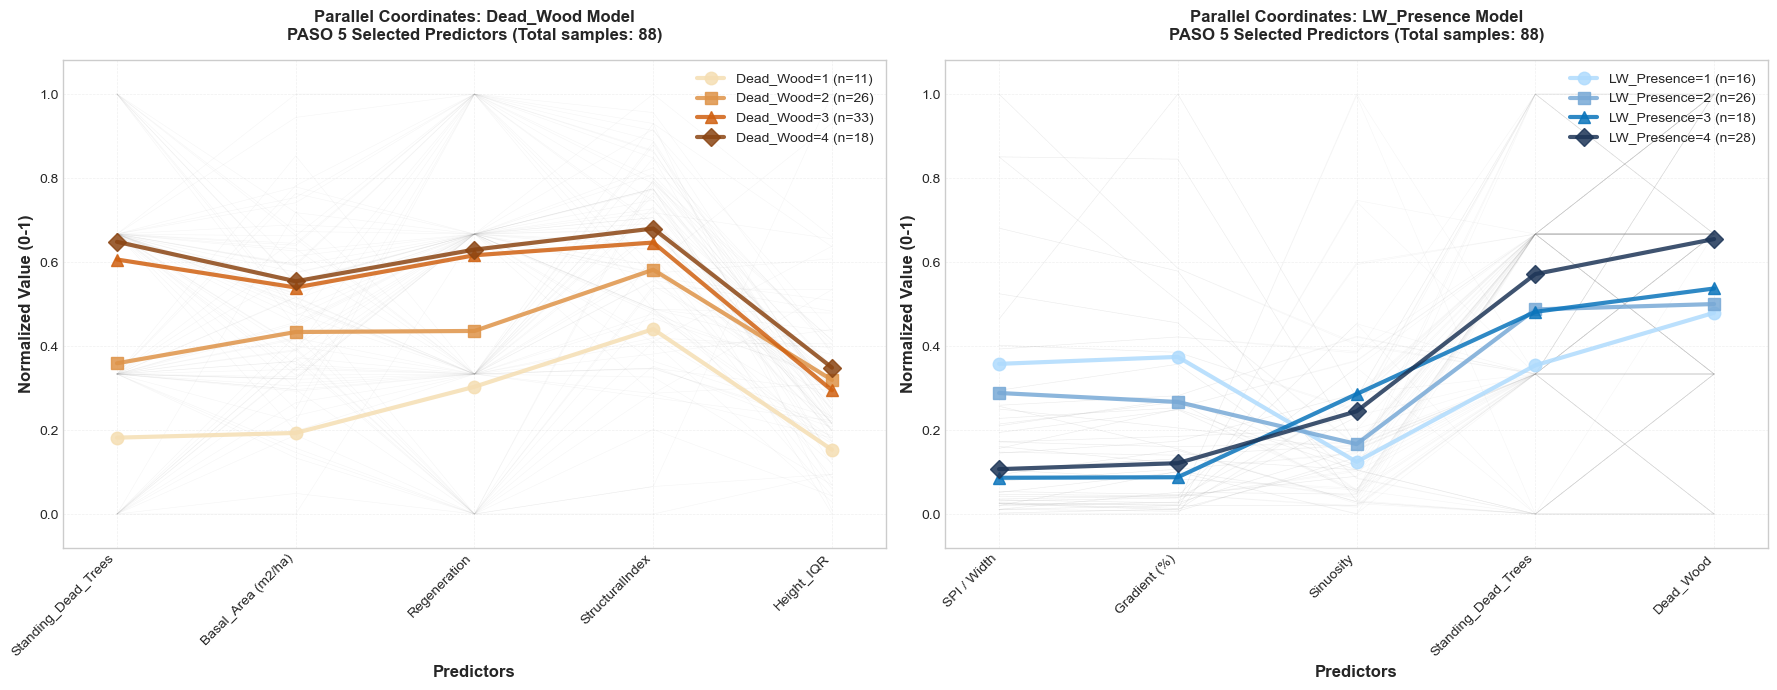


SUMMARY STATISTICS

✓ Dead_Wood Model:
  - Total samples: 88
  - Category distribution:
    → Dead_Wood=1:   11 samples ( 12.5%)
    → Dead_Wood=2:   26 samples ( 29.5%)
    → Dead_Wood=3:   33 samples ( 37.5%)
    → Dead_Wood=4:   18 samples ( 20.5%)

✓ LW_Presence Model:
  - Total samples: 88
  - Category distribution:
    → LW_Presence=1:   16 samples ( 18.2%)
    → LW_Presence=2:   26 samples ( 29.5%)
    → LW_Presence=3:   18 samples ( 20.5%)
    → LW_Presence=4:   28 samples ( 31.8%)

COLOR PALETTE INTERPRETATION

✓ Dead_Wood colors (Brown gradient - Understory structure intensity):
  - Category 1 (Wheat/Light):    #F5DEB3 - Low dead wood intensity
  - Category 2 (Peru):            #DE9348 - Medium-low dead wood intensity
  - Category 3 (Chocolate):       #D06111 - Medium-high dead wood intensity
  - Category 4 (Saddle brown):    #8B4513 - High dead wood intensity

✓ LW_Presence colors (Blue gradient - Channel energy/wood retention):
  - Category 1 (Very light blue): #AFDBFD - L

In [58]:
# Parallel Coordinates Plot - Custom Predictor Sets from PASO 5
# Using selected predictors from PASO 5 final decision logic with global color palettes

# Define custom feature sets based on PASO 5 selection
deadwood_features_custom = ['Standing_Dead_Trees', 'Basal_Area (m2/ha)', 'Regeneration', 'StructuralIndex', 'Height_IQR']
lw_features_custom = ['SPI / Width', 'Gradient (%)', 'Sinuosity', 'Standing_Dead_Trees', 'Dead_Wood']

print("=" * 110)
print("PARALLEL COORDINATES: PASO 5 Custom Predictor Sets")
print("=" * 110)
print(f"\n✓ Dead_Wood model predictors ({len(deadwood_features_custom)}):")
for i, feat in enumerate(deadwood_features_custom, 1):
    print(f"   {i}. {feat}")

print(f"\n✓ LW_Presence model predictors ({len(lw_features_custom)}):")
for i, feat in enumerate(lw_features_custom, 1):
    print(f"   {i}. {feat}")

# Prepare Dead_Wood data with custom features
print("\nPreparing data...")
prep_data_dw_custom = df_dead_wood[deadwood_features_custom + ['Dead_Wood_Category']].dropna()
scaler_dw_custom = MinMaxScaler()
prep_data_normalized_dw_custom = prep_data_dw_custom.copy()
prep_data_normalized_dw_custom[deadwood_features_custom] = scaler_dw_custom.fit_transform(prep_data_dw_custom[deadwood_features_custom])

# Prepare LW_Presence data with custom features
# Ensure LW_Presence_Category column exists (create if needed)
if 'LW_Presence_Category' not in df_lw.columns:
    df_lw['LW_Presence_Category'] = df_lw['LW_Presence'].astype(str)
prep_data_lw_custom = df_lw[lw_features_custom + ['LW_Presence_Category']].dropna()
scaler_lw_custom = MinMaxScaler()
prep_data_normalized_lw_custom = prep_data_lw_custom.copy()
prep_data_normalized_lw_custom[lw_features_custom] = scaler_lw_custom.fit_transform(prep_data_lw_custom[lw_features_custom])

# Create parallel coordinates plots with global color palettes
markers = {1: 'o', 2: 's', 3: '^', 4: 'D'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

data_sets_custom = [
    ('Dead_Wood', prep_data_normalized_dw_custom, 'Dead_Wood_Category', deadwood_features_custom, dw_class_colors),
    ('LW_Presence', prep_data_normalized_lw_custom, 'LW_Presence_Category', lw_features_custom, lw_class_colors)
]

for idx, (target_name, data, category_col, features, color_palette) in enumerate(data_sets_custom):
    ax = axes[idx]
    n_samples = len(data)
    
    # Plot individual samples (light gray lines) for context
    for _, row in data.iterrows():
        positions = np.arange(len(features))
        values = [row[feat] for feat in features]
        ax.plot(positions, values, alpha=0.08, color='gray', linewidth=0.4)
    
    # Plot mean profiles (thick colored lines) by category using global color palettes
    for category in sorted(data[category_col].unique()):
        subset = data[data[category_col] == category]
        positions = np.arange(len(features))
        mean_values = [subset[feat].mean() for feat in features]
        cat_int = int(category)
        ax.plot(positions, mean_values, linewidth=3, marker=markers[cat_int], 
               label=f'{target_name}={cat_int} (n={len(subset)})', markersize=9, 
               alpha=0.85, color=color_palette[cat_int])
    
    # Formatting
    ax.set_xlabel('Predictors', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Value (0-1)', fontsize=12, fontweight='bold')
    ax.set_title(f'Parallel Coordinates: {target_name} Model\nPASO 5 Selected Predictors (Total samples: {n_samples})', 
                fontsize=12, fontweight='bold', pad=15)
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(features, rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=10, loc='upper right', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_ylim(-0.08, 1.08)
    ax.set_xlim(-0.3, len(features)-0.7)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 110)
print("SUMMARY STATISTICS")
print("=" * 110)

print(f"\n✓ Dead_Wood Model:")
print(f"  - Total samples: {len(prep_data_normalized_dw_custom)}")
print(f"  - Category distribution:")
for cat in sorted(prep_data_dw_custom['Dead_Wood_Category'].unique()):
    count = len(prep_data_dw_custom[prep_data_dw_custom['Dead_Wood_Category'] == cat])
    pct = 100 * count / len(prep_data_dw_custom)
    print(f"    → Dead_Wood={int(cat)}: {count:4d} samples ({pct:5.1f}%)")

print(f"\n✓ LW_Presence Model:")
print(f"  - Total samples: {len(prep_data_normalized_lw_custom)}")
print(f"  - Category distribution:")
for cat in sorted(prep_data_lw_custom['LW_Presence_Category'].unique()):
    count = len(prep_data_lw_custom[prep_data_lw_custom['LW_Presence_Category'] == cat])
    pct = 100 * count / len(prep_data_lw_custom)
    print(f"    → LW_Presence={int(cat)}: {count:4d} samples ({pct:5.1f}%)")

print("\n" + "=" * 110)
print("COLOR PALETTE INTERPRETATION")
print("=" * 110)
print(f"""
✓ Dead_Wood colors (Brown gradient - Understory structure intensity):
  - Category 1 (Wheat/Light):    {dw_class_colors[1]} - Low dead wood intensity
  - Category 2 (Peru):            {dw_class_colors[2]} - Medium-low dead wood intensity
  - Category 3 (Chocolate):       {dw_class_colors[3]} - Medium-high dead wood intensity
  - Category 4 (Saddle brown):    {dw_class_colors[4]} - High dead wood intensity

✓ LW_Presence colors (Blue gradient - Channel energy/wood retention):
  - Category 1 (Very light blue): {lw_class_colors[1]} - Low LW presence
  - Category 2 (Medium blue):     {lw_class_colors[2]} - Medium-low LW presence
  - Category 3 (Dark blue):       {lw_class_colors[3]} - Medium-high LW presence
  - Category 4 (Deep blue):       {lw_class_colors[4]} - High LW presence (channel energy-controlled)

Marker symbols by category:
  → Circle (o) = Category 1
  → Square (s) = Category 2  
  → Triangle (^) = Category 3
  → Diamond (D) = Category 4

Key insights from parallel coordinates:
  • Parallel lines across features = strong intercorrelation
  • Diverging lines = predictor differentiates the response category
  • Clustering of lines = homogeneous predictor patterns within categories
  • High variability in individual lines = high within-category heterogeneity
""")

In [59]:
# ==================== DATA PREPARATION FOR VISUALIZATIONS ====================
# Create filtered dataframes and category columns for Dead_Wood and LW_Presence

print("=" * 110)
print("DATA PREPARATION: Creating filtered datasets and category columns")
print("=" * 110)

# Import MinMaxScaler for normalization
from sklearn.preprocessing import MinMaxScaler

# Create Dead_Wood dataset with valid values (1, 2, 3, 4)
df_dead_wood = df[df['Dead_Wood'].isin([1, 2, 3, 4])].copy()
df_dead_wood['Dead_Wood_Category'] = df_dead_wood['Dead_Wood'].astype(str)

print(f"\n✓ Dead_Wood dataset:")
print(f"  - Samples: {len(df_dead_wood)}")
print(f"  - Category distribution:")
for cat in sorted(df_dead_wood['Dead_Wood'].unique()):
    count = len(df_dead_wood[df_dead_wood['Dead_Wood'] == cat])
    pct = 100 * count / len(df_dead_wood)
    print(f"    → Category {int(cat)}: {count:4d} samples ({pct:5.1f}%)")

# Create LW_Presence dataset with valid values (1, 2, 3, 4)
df_lw = df[df['LW_Presence'].isin([1, 2, 3, 4])].copy()
df_lw['LW_Presence_Category'] = df_lw['LW_Presence'].astype(str)

print(f"\n✓ LW_Presence dataset:")
print(f"  - Samples: {len(df_lw)}")
print(f"  - Category distribution:")
for cat in sorted(df_lw['LW_Presence'].unique()):
    count = len(df_lw[df_lw['LW_Presence'] == cat])
    pct = 100 * count / len(df_lw)
    print(f"    → Category {int(cat)}: {count:4d} samples ({pct:5.1f}%)")

print(f"\n✓ Data preparation complete. Ready for visualization.")

DATA PREPARATION: Creating filtered datasets and category columns

✓ Dead_Wood dataset:
  - Samples: 88
  - Category distribution:
    → Category 1:   11 samples ( 12.5%)
    → Category 2:   26 samples ( 29.5%)
    → Category 3:   33 samples ( 37.5%)
    → Category 4:   18 samples ( 20.5%)

✓ LW_Presence dataset:
  - Samples: 88
  - Category distribution:
    → Category 1:   16 samples ( 18.2%)
    → Category 2:   26 samples ( 29.5%)
    → Category 3:   18 samples ( 20.5%)
    → Category 4:   28 samples ( 31.8%)

✓ Data preparation complete. Ready for visualization.


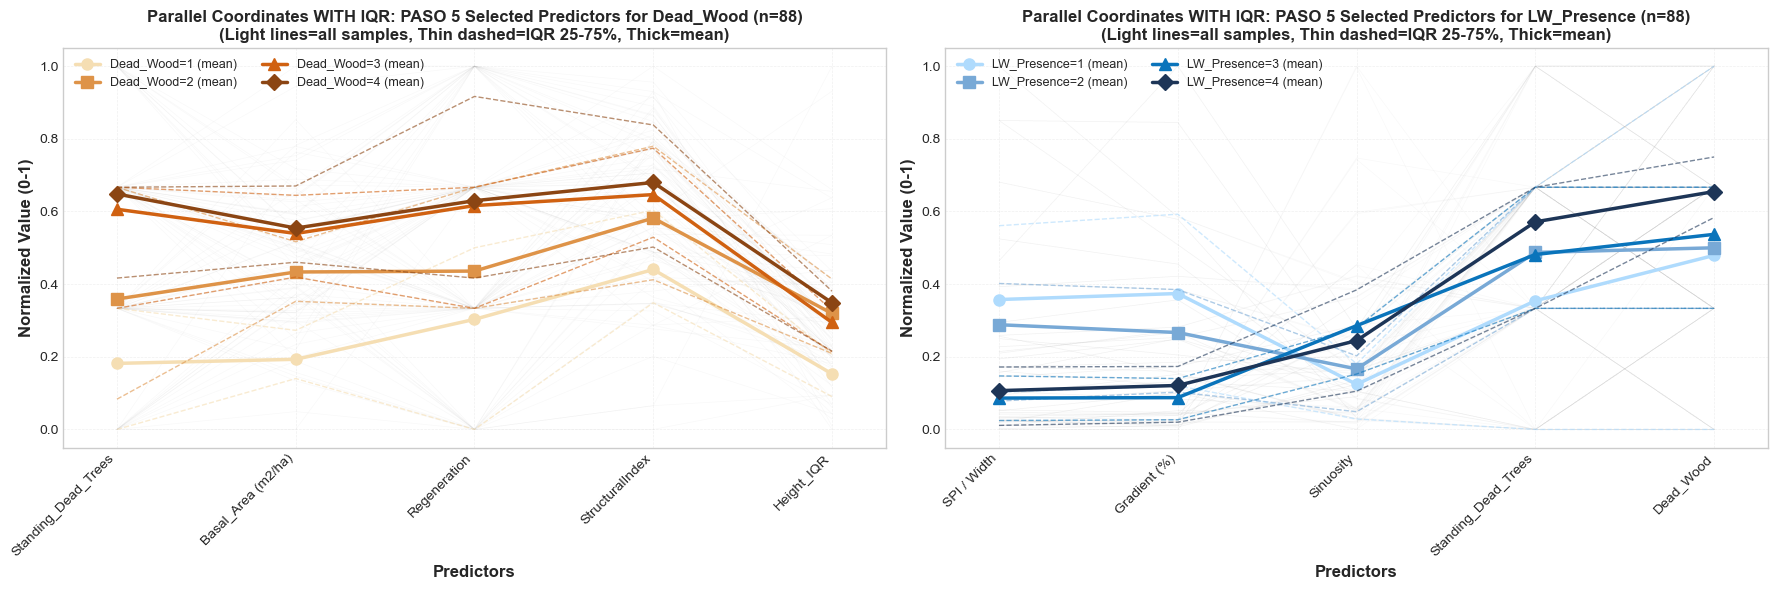


PARALLEL COORDINATES WITH IQR - PASO 5 CUSTOM PREDICTORS

Visualization Components:
  • Light gray lines: Individual observations (all samples)
  • Thin dashed lines: 25th and 75th percentile bounds (Interquartile Range)
  • Thick colored lines: Mean profiles for each category
  
Marker Symbols by Category:
  → Circle (o) = Category 1
  → Square (s) = Category 2
  → Triangle (^) = Category 3
  → Diamond (D) = Category 4

Color Interpretations:
  Dead_Wood (Brown gradient):
    • Light brown (#F5DEB3) = Category 1 (Low dead wood)
    • Medium browns (#DE9348 → #D06111) = Categories 2-3
    • Dark brown (#8B4513) = Category 4 (High dead wood)
  
  LW_Presence (Blue gradient):
    • Light blue (#AFDBFD) = Category 1 (Low LW presence)
    • Medium/dark blues (#78A9D6 → #0A74BB) = Categories 2-3
    • Deep blue (#1D3557) = Category 4 (High LW presence)

Key Insights from Parallel Coordinates:
  • Parallel lines across features = strong predictor intercorrelation
  • Diverging lines = predi

In [60]:
# Parallel Coordinates Plot WITH IQR BANDS - Custom PASO 5 Predictors
# Same as above but includes IQR (25-75%) as thin lines in same color as mean using global palettes

markers = {1: 'o', 2: 's', 3: '^', 4: 'D'}
# Use global color palettes defined at the beginning
colors_dw = dw_class_colors
colors_lw = lw_class_colors

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

data_sets = [
    ('Dead_Wood', prep_data_normalized_dw_custom, 'Dead_Wood_Category', deadwood_features_custom, colors_dw),
    ('LW_Presence', prep_data_normalized_lw_custom, 'LW_Presence_Category', lw_features_custom, colors_lw)
]

for idx, (target_name, data, category_col, features, colors_palette) in enumerate(data_sets):
    ax = axes[idx]
    n_samples = len(data)
    
    # Plot individual samples (light lines)
    for _, row in data.iterrows():
        positions = np.arange(len(features))
        values = [row[feat] for feat in features]
        ax.plot(positions, values, alpha=0.05, color='gray', linewidth=0.5)
    
    # Plot mean profiles with IQR thin lines
    for category in sorted(data[category_col].unique()):
        subset = data[data[category_col] == category]
        positions = np.arange(len(features))
        
        # Calculate mean and IQR for each feature
        mean_values = []
        q25_values = []
        q75_values = []
        
        for feat in features:
            mean_values.append(subset[feat].mean())
            q25_values.append(subset[feat].quantile(0.25))
            q75_values.append(subset[feat].quantile(0.75))
        
        cat_int = int(category)
        cat_color = colors_palette[cat_int]
        
        # Plot Q25 and Q75 as thin lines with same color as mean
        ax.plot(positions, q25_values, linewidth=1, color=cat_color, alpha=0.6, linestyle='--')
        ax.plot(positions, q75_values, linewidth=1, color=cat_color, alpha=0.6, linestyle='--')
        
        # Plot mean line on top with distinct marker per category
        ax.plot(positions, mean_values, linewidth=2.5, marker=markers[cat_int], 
                label=f'{target_name}={cat_int} (mean)', markersize=8, color=cat_color)
    
    ax.set_xlabel('Predictors', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Value (0-1)', fontsize=12, fontweight='bold')
    ax.set_title(f'Parallel Coordinates WITH IQR: PASO 5 Selected Predictors for {target_name} (n={n_samples})\n(Light lines=all samples, Thin dashed=IQR 25-75%, Thick=mean)', 
                fontsize=12, fontweight='bold')
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(features, rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.3, len(features)-0.7)

plt.tight_layout()
plt.show()

print("\n" + "=" * 110)
print("PARALLEL COORDINATES WITH IQR - PASO 5 CUSTOM PREDICTORS")
print("=" * 110)
print("""
Visualization Components:
  • Light gray lines: Individual observations (all samples)
  • Thin dashed lines: 25th and 75th percentile bounds (Interquartile Range)
  • Thick colored lines: Mean profiles for each category
  
Marker Symbols by Category:
  → Circle (o) = Category 1
  → Square (s) = Category 2
  → Triangle (^) = Category 3
  → Diamond (D) = Category 4

Color Interpretations:
  Dead_Wood (Brown gradient):
    • Light brown (#F5DEB3) = Category 1 (Low dead wood)
    • Medium browns (#DE9348 → #D06111) = Categories 2-3
    • Dark brown (#8B4513) = Category 4 (High dead wood)
  
  LW_Presence (Blue gradient):
    • Light blue (#AFDBFD) = Category 1 (Low LW presence)
    • Medium/dark blues (#78A9D6 → #0A74BB) = Categories 2-3
    • Deep blue (#1D3557) = Category 4 (High LW presence)

Key Insights from Parallel Coordinates:
  • Parallel lines across features = strong predictor intercorrelation
  • Diverging lines = predictor differentiates the response category well
  • Convergence of lines = predictor has low discriminative power
  • Tight IQR bounds = homogeneous category patterns (low within-category variability)
  • Wide IQR bounds = heterogeneous patterns (high within-category variability)
""")